<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/non_sequential_model_functionalAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('kaggle_key')
os.environ["KAGGLE_USERNAME"] = userdata.get('kaggle_username')

In [9]:
! kaggle datasets download -d jangedoo/utkface-new

! unzip "utkface-new.zip"

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
utkface-new.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  utkface-new.zip
replace UTKFace/100_0_0_20170112213500903.jpg.chip.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [11]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
folder_path = '/content/utkface_aligned_cropped/UTKFace'

In [13]:
age=[]
gender=[]
img_path=[]
for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))
  gender.append(int(file.split('_')[1]))
  img_path.append(file)

In [14]:
len(age)

23708

In [15]:
df = pd.DataFrame({'age':age,'gender':gender,'img':img_path})

In [16]:
df.shape

(23708, 3)

In [17]:
df.head()

,age,gender,img
0,14,0,14_0_4_20170103205138666.jpg.chip.jpg
1,40,1,40_1_0_20170117181413925.jpg.chip.jpg
2,26,0,26_0_0_20170117090952435.jpg.chip.jpg
3,30,0,30_0_1_20170113133914136.jpg.chip.jpg
4,39,1,39_1_0_20170105184017031.jpg.chip.jpg


In [18]:
train_df = df.sample(frac=1,random_state=0).iloc[:20000]
test_df = df.sample(frac=1,random_state=0).iloc[20000:]

In [19]:
train_df.shape

(20000, 3)

In [20]:
test_df.shape

(3708, 3)

In [21]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

In [29]:
train_generator = train_datagen.flow_from_dataframe(train_df,                    # df for data
                                                    directory=folder_path,
                                                    x_col='img',
                                                    y_col=['age','gender'],
# multi-class, hence requires custom_generator as below to get correct format of labels - dict not list
                                                    target_size=(200,200),
                                                    class_mode='multi_output')   # class mode

test_generator = test_datagen.flow_from_dataframe(test_df,
                                                    directory=folder_path,
                                                    x_col='img',
                                                    y_col=['age','gender'],
                                                    target_size=(200,200),
                                                  class_mode='multi_output')

# Custom generator to yield outputs as a dictionary
def custom_generator(generator):
    while True:
        x, y = next(generator)
        yield x, {'age': y[0], 'gender': y[1]}

train_generator_dict = custom_generator(train_generator)
test_generator_dict = custom_generator(test_generator)

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [23]:
from keras.applications.resnet50 import ResNet50
from keras.layers import *
from keras.models import Model

In [24]:
resnet = ResNet50(include_top=False, input_shape=(200,200,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [25]:
resnet = ResNet50(include_top=False, input_shape=(200,200,3))

resnet.trainable=False

output = resnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512, activation='relu')(flatten)
dense2 = Dense(512,activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1,activation='linear',name='age')(dense3)
output2 = Dense(1,activation='sigmoid',name='gender')(dense4)

In [26]:
model = Model(inputs=resnet.input,outputs=[output1,output2])

In [40]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 206, 206,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 100, 100,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 100, 100,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 100, 100,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 102, 102,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 50, 50,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 50, 50,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 50, 50,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 50, 50,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 50, 50,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 50, 50,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 50, 50,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 50, 50,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 50, 50,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 50, 50,    │      1,024 │ conv2_block1_3_c

 Total params: 333,451,144 (1.24 GB)

 Trainable params: 103,287,810 (394.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 206,575,622 (788.02 MB)

In [27]:
model.compile(optimizer='adam', loss={'age': 'mae', 'gender': 'binary_crossentropy'}, metrics={'age': 'mae', 'gender': 'accuracy'},loss_weights={'age':1,'gender':99})

In [38]:
model.fit(train_generator_dict, epochs=3, validation_data=test_generator_dict, steps_per_epoch=len(train_generator), validation_steps=len(test_generator))

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 227s 364ms/step - age_loss: 14.7607 - age_mae: 14.7607 - gender_accuracy: 0.5217 - gender_loss: 0.6924 - loss: 83.3091 - val_age_loss: 14.5254 - val_age_mae: 14.5257 - val_gender_accuracy: 0.5151 - val_gender_loss: 0.6930 - val_loss: 83.1393
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 218s 350ms/step - age_loss: 14.7065 - age_mae: 14.7065 - gender_accuracy: 0.5212 - gender_loss: 0.6933 - loss: 83.3425 - val_age_loss: 14.2042 - val_age_mae: 14.2082 - val_gender_accuracy: 0.5154 - val_gender_loss: 0.6930 - val_loss: 82.8149
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 229s 367ms/step - age_loss: 14.4667 - age_mae: 14.4667 - gender_accuracy: 0.5189 - gender_loss: 0.6948 - loss: 83.2535 - val_age_loss: 14.1737 - val_age_mae: 14.1729 - val_gender_accuracy: 0.5194 - val_gender_loss: 0.6926 - val_loss: 82.7457


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Predicted Age: 32.923527, actual age: 30
Predicted Gender: Female, actual gender: 0
Predicted Gender Probability: 0.469162


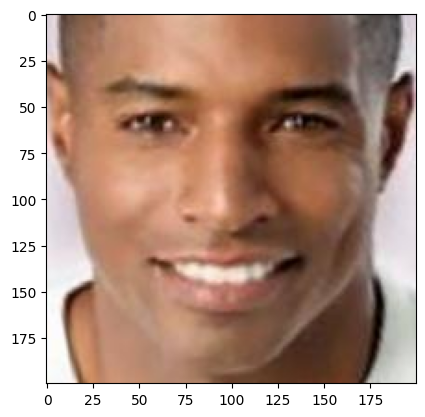

In [48]:
# @title inference:
from tensorflow.keras.preprocessing import image
import numpy as np
image_num = 3

img_path = os.path.join(folder_path, df['img'][image_num])
img = image.load_img(img_path, target_size=(200, 200))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model.predict(img_array)

# The predictions will be a list of arrays, one for each output
predicted_age = predictions[0][0][0]
predicted_gender_prob = predictions[1][0][0]
predicted_gender = 'Male' if predicted_gender_prob > 0.5 else 'Female'
age = df["age"][image_num]
gender = df["gender"][image_num]

print(f"Predicted Age: {predicted_age:.6f}, actual age: {age}")
print(f"Predicted Gender: {predicted_gender}, actual gender: {gender}")
print(f"Predicted Gender Probability: {predicted_gender_prob:.6f}")

import matplotlib.pyplot as plt
plt.imshow(img_array[0])
plt.show()